# 02 Impact de la résolution spatiale

---
##  Objectif
Ce notebook évalue l'effet d'une dégradation spatiale de la résolution sur la représentation du Gulf Stream.

L'objectif est de comparer les diagnostics obtenus à partir de GLORYS12V1 en résolution native **1/12°** avec une version dégradée en **pseudo-1/4°**.

---

##  Plan 
### I. Construction de la résolution pseudo-1/4°
- Sélection du domaine Gulf Stream
- Dégradation spatiale par **Coarsen**

### II. Représentation des fronts océaniques
- Gradient SST HR vs pseudo-1/4°
- Gradient SSH HR vs pseudo-1/4°

### III. Quantification statistique
- CCDF des gradients SST
- Tableau des percentiles

### IV. Bilan 

---
## Progression du projet Github 
- ⬜ 01 Analyse des proxys de surface 
- 🟦 02 Impact de la résolution spatiale *(vous êtes ici)*
- ⬜ 03 Conclusion
---

## I. Domaine d'étude et diminution de la résolution

### Méthode

La comparaison est réalisée sur une région couvrant le Gulf Stream
(30–50°N ; 80–40°W).

En effet cette zone concentre :
- les gradients thermiques les plus marqués de l'Atlantique Nord ;
- les principaux fronts océaniques ;
- une forte activité de méso-échelle (méandres et tourbillons).

Elle constitue donc un domaine adapté pour évaluer l'influence de la résolution spatiale sur la représentation des structures fines.

La fonction Coarsen consiste à récupérer la moyenne de 3 pixels en longitude par 3 pixels en latitude afin d'obtenir un lissage spatial.

 >**RMQ:** 
 >Naturellement, le résultat n'est pas le même que pour une simulation construite avec une résolution de 1/4° qui n'intégrerait pas la résolution des structures méso-échelle




/Users/seph/miniforge3/envs/amoc/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


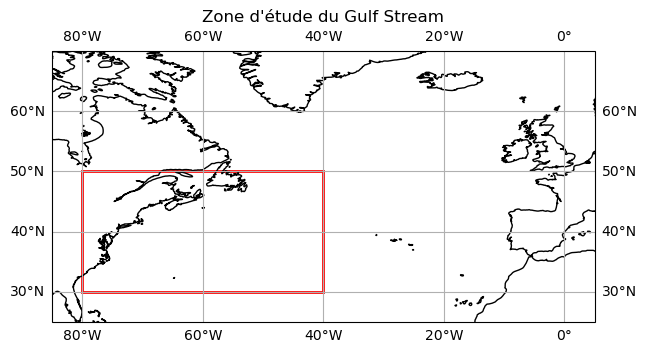

In [ ]:
import fonction as fct
sst, sss, ssh = fct.extraction_proxies()

# Domaine Gulf Stream
sst_gs = fct.selection_gulf_stream(sst)
ssh_gs = fct.selection_gulf_stream(ssh)

# Resolution pseudo-1/4°
sst_gs_lr = fct.degradation_resolution(sst_gs)
ssh_gs_lr = fct.degradation_resolution(ssh_gs)

#GENERATION D'UNE CARTE DE LA ZONE DU GULF STREAM
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Coordonnées de l'étude
lon_min, lon_max = -80, -40
lat_min, lat_max = 30, 50

fig = plt.figure(figsize=(7, 4))
ax = plt.axes(projection=ccrs.PlateCarree())

# Domaine Atlantique Nord
ax.set_extent([-85, 5, 25, 70], crs=ccrs.PlateCarree())

# Fond de carte 
ax.coastlines()
ax.gridlines(draw_labels=True)

# Rectangle zone d'étude
rect = patches.Rectangle((lon_min, lat_min),lon_max - lon_min,lat_max - lat_min,linewidth=2,edgecolor="red",facecolor="none",transform=ccrs.PlateCarree())
ax.add_patch(rect)
ax.set_title("Zone d'étude du Gulf Stream")

plt.show()

## II. Représentation des fronts océaniques

### Question scientifique

La diminution de la résolution spatiale modifie-t-elle la représentation des fronts océaniques ?

### Méthode

Les fronts sont caractérisés par la norme du gradient horizontal des champs SST et SSH.

$$|\nabla X|=\sqrt{\left(\frac{\partial X}{\partial x}\right)^2+\left(\frac{\partial X}{\partial y}\right)^2}$$

avec :
- $X =$ SST ou SSH.

Afin de représenter les fronts les plus intenses, le 95ᵉ percentile temporel est calculé en chaque point de la grille.



/Users/seph/miniforge3/envs/amoc/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


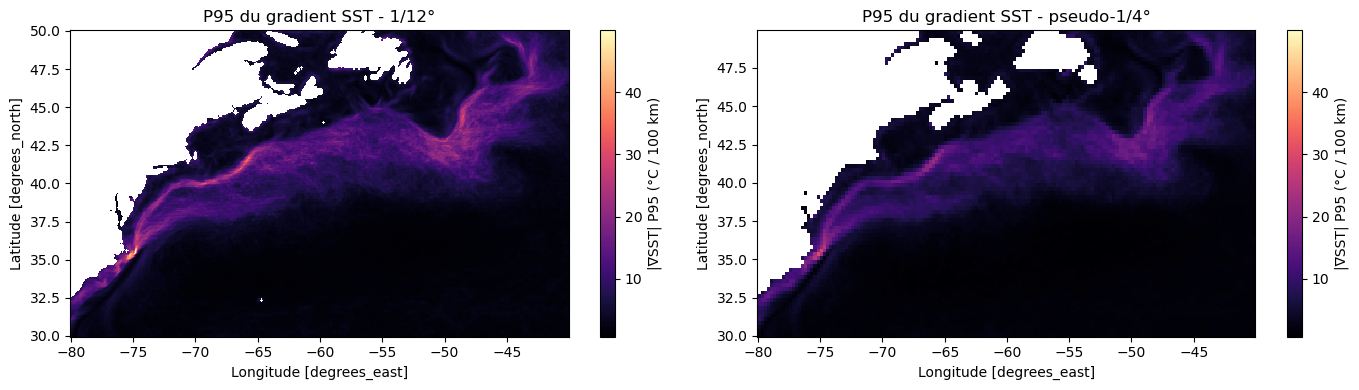

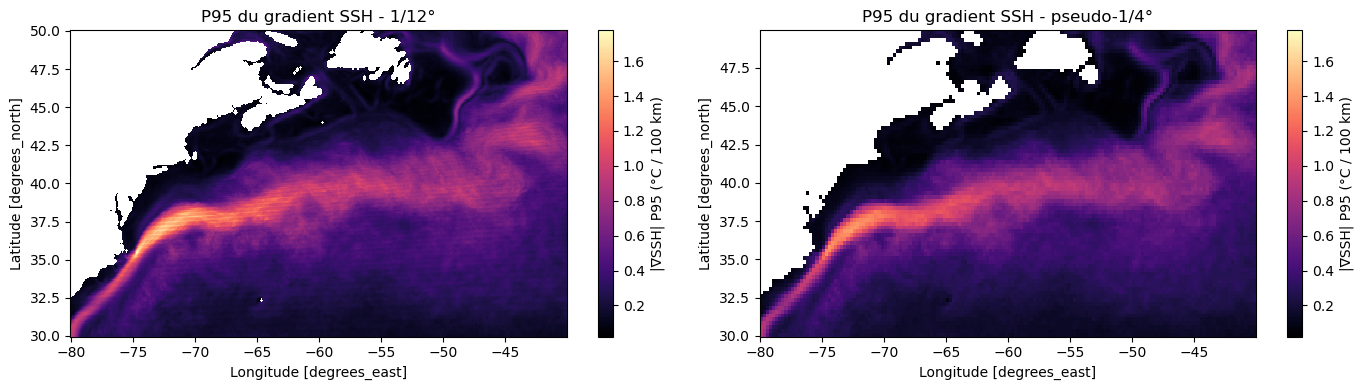

In [5]:
#SST
grad_sst_hr = fct.gradient_p95(sst_gs) * 100000 # conversion en °C / 100 km
grad_sst_lr = fct.gradient_p95(sst_gs_lr) * 100000

#SSH
grad_ssh_hr = fct.gradient_p95 (ssh_gs) * 100000 # conversion en °C / 100 km
grad_ssh_lr = fct.gradient_p95(ssh_gs_lr) * 100000

fct.carte(carte1=grad_sst_hr,titre1="P95 du gradient SST - 1/12°",titre1_cbar="|∇SST| P95 (°C / 100 km)",
          carte2=grad_sst_lr,titre2="P95 du gradient SST - pseudo-1/4°",titre2_cbar="|∇SST| P95 (°C / 100 km)",
          cmap="magma", figsize=(14,4),same_scale=True)

fct.carte(carte1=grad_ssh_hr,titre1="P95 du gradient SSH - 1/12°",titre1_cbar="|∇SSH| P95 (°C / 100 km)",
          carte2=grad_ssh_lr,titre2="P95 du gradient SSH - pseudo-1/4°",titre2_cbar="|∇SSH| P95 (°C / 100 km)",
          cmap="magma", figsize=(14,4),same_scale=True)


### Interprétation
- La diminution de résolution conserve la position générale du Gulf Stream, mais atténue les gradients les plus intenses.
- Elle lisse partiellement les petites structures ce qui réduit la représentation de la dynamique de méso-échelle.

 On peut donc se demander dans quelle mesure ce lissage intervient et comment évolue la probabilité d'observer des gradients de plus en plus intenses avec ces deux résolutions. 


## IV. Quantification des pertes de gradients
### Axe d'analyse
Comment quantifier l'effet de la résolution spatiale sur la distribution statistique des gradients de SST ? 

### Méthode

Les gradients mensuels de SST sont d'abord convertis en vecteurs unidimensionnels puis filtrés et triés par ordre croissant. 

À partir de ces valeurs triées, une fonction de distribution cumulative complémentaire (Complementary Cumulative Distribution Function, **CCDF**) est calculée.

La CCDF représente la probabilité qu'un gradient soit supérieur à une valeur donnée :
$$S(x)=P(X>x)$$

Elle permet d'étudier spécifiquement les événements extrêmes, c'est-à-dire les gradients les plus intenses.


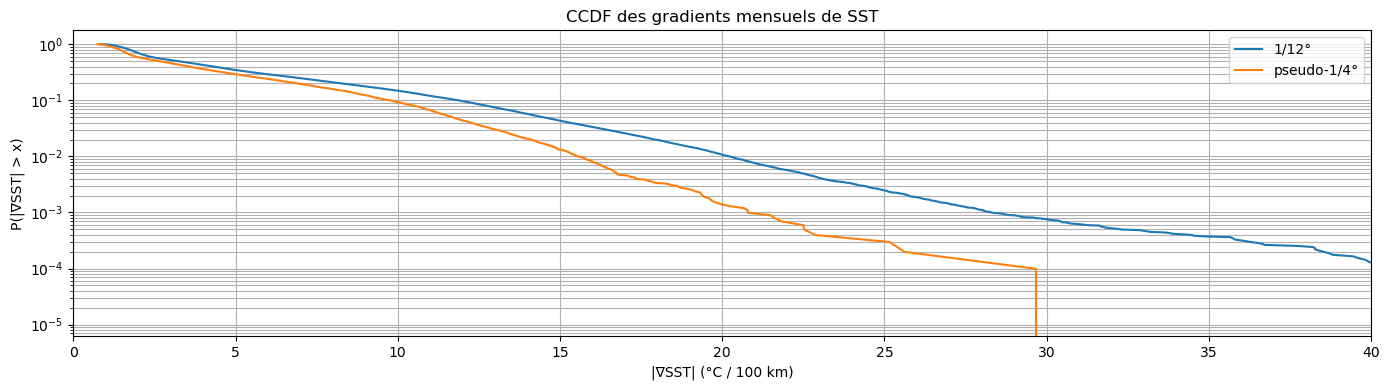

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Transforme les vecteurs en  1D
hr = grad_sst_hr.values.ravel()
lr = grad_sst_lr.values.ravel()

# Enleve les NaN
hr = hr[~np.isnan(hr)]
lr = lr[~np.isnan(lr)]

# Trie les valeurs
hr_sorted = np.sort(hr)
lr_sorted = np.sort(lr)

# CCDF : P(grad(SST) > x)
hr_ccdf = 1 - np.arange(1, len(hr_sorted) + 1) / len(hr_sorted)
lr_ccdf = 1 - np.arange(1, len(lr_sorted) + 1) / len(lr_sorted)

plt.figure(figsize=(14, 4))

#Les courbes sont en semi-logarithmique pour mieux visualiser les queues de distribution
plt.semilogy(hr_sorted, hr_ccdf, label="1/12°")
plt.semilogy(lr_sorted, lr_ccdf, label="pseudo-1/4°")

plt.xlabel("|∇SST| (°C / 100 km)")
plt.ylabel("P(|∇SST| > x)")
plt.title("CCDF des gradients mensuels de SST")
plt.legend()
plt.grid(True, which="both")
plt.xlim(0, 40)

plt.tight_layout()
plt.show()

### Interprétation 
La diminution de résolution modifie peu les gradients faibles, qui restent dominés par la circulation de grande échelle.
En revanche, elle réduit fortement les gradients élevés, correspondant aux fronts les plus intenses.
La disparition de la queue de distribution à basse résolution traduit un lissage des fronts océaniques et une perte des structures fines de méso-échelle.

### Méthode 
Afin de quantifier cette différence, les percentiles P50, P75, P90, P95 et P99 sont calculés sur la distribution de la simulation 1/12°.
Pour chacun de ces seuils, la fraction d'observations dépassant cette valeur est calculée dans les deux simulations.
Cette approche permet d'évaluer dans quelle mesure les gradients caractéristiques de la haute résolution sont encore représentés après dégradation spatiale.

In [8]:
import pandas as pd

percentiles = [50, 75, 90, 95, 99]
rows = []

for p in percentiles:

    # Récupère le seuil correspondant au percentile dans HR
    seuil = np.percentile(hr, p)

    #Pourcentage  d'observations dépassant ce seuil 
    fraction_hr = np.mean(hr > seuil) * 100
    fraction_lr = np.mean(lr > seuil) * 100

    perte = (1 - fraction_lr / fraction_hr) * 100
    rows.append({"Percentile HR": f"P{p}","Seuil (°C/100 km)": seuil,"1/12° (%)": fraction_hr,"Pseudo-1/4° (%)": fraction_lr,"Perte (%)": perte})

tableau_sst = pd.DataFrame(rows)
tableau_sst.round(2)

,Percentile HR,Seuil (°C/100 km),1/12° (%),Pseudo-1/4° (%),Perte (%)
0,P50,3.23,50.0,43.37,13.25
1,P75,6.96,25.0,19.82,20.72
2,P90,11.87,10.0,4.64,53.57
3,P95,14.48,5.0,1.71,65.88
4,P99,20.22,1.0,0.14,86.12


### Interprétation 

- Pour les fronts les plus intenses (P95, 14,48 °C/100 km), la fraction d’observations diminue de 5,0 % à 1,71 %, soit une perte de 65,88 %.
- Enfin, les gradients extrêmes (P99, 20,22 °C/100 km) sont les plus affectés : la fréquence chute de 1,0 % à 0,14 %, ainsi 86,12 % des événements extrêmes ne sont plus considérés comme assez forts pour dépasser ce seuil avec la résolution pseudo 1/4 ° .
 
 
Les gradients les plus intenses sont donc au moins deux fois plus fréquents dans la simulation haute résolution.


## Bilan 
Ces résultats montrent que la dégradation de la résolution spatiale ne modifie pas que l'apparence des cartes, mais modifie aussi la distribution statistique des gradients. Les structures les plus énergétiques deviennent moins fréquentes, ce qui confirme que la haute résolution est essentielle pour représenter correctement les fronts océaniques associés au Gulf Stream.

